# ForecastLab

---

## Bike Sharing Demand Forecasting

---

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-001 |
| **Eksperimen** | EXP-013 |
| **Nama Eksperimen** | Error Analysis & Model Evaluation |
| **Dataset** | featured_data.csv |
| **Tujuan Notebook** | Membandingkan seluruh model dan menganalisis karakteristik error |
| **Author** | GAKUSEI Najib |

---

## 1. Tujuan

Membandingkan performa seluruh model secara side-by-side dan menganalisis pola error.

## Hipotesis
Error tidak terjadi secara acak — terdapat pola berdasarkan jam, musim, atau kondisi cuaca.

---
## 2. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
print('Library berhasil diimport.')

Library berhasil diimport.


---
## 3. Load Dataset

In [2]:
INPUT_PATH = '../data/featured_data.csv'
df = pd.read_csv(INPUT_PATH)
df['dteday'] = pd.to_datetime(df['dteday'])
df = df.sort_values(by=['dteday', 'hr']).reset_index(drop=True)

exclude_cols = ['dteday', 'cnt', 'temp_actual', 'atemp_actual']
feature_cols = [c for c in df.columns if c not in exclude_cols]

train = df[df['yr'] == 0].copy()
test  = df[df['yr'] == 1].copy()

X_train = train[feature_cols].copy()
y_train = train['cnt'].copy()
X_test  = test[feature_cols].copy()
y_test  = test['cnt'].copy()

train_valid = X_train.dropna().index
X_train = X_train.loc[train_valid]
y_train = y_train.loc[train_valid]
test_valid = X_test.dropna().index
X_test = X_test.loc[test_valid]
y_test = y_test.loc[test_valid]

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (8477, 41), X_test: (8734, 41)


---
## 4. Train All Models

In [3]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=7, random_state=42),
}

try:
    import xgboost as xgb
    models['XGBoost'] = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=7, random_state=42)
except ImportError:
    print('XGBoost tidak terinstall, akan dilewati.')

results = []
predictions = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    t_train = time.time() - t0
    
    yp_train = model.predict(X_train)
    yp_test  = model.predict(X_test)
    predictions[name] = yp_test
    
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, yp_test),
        'RMSE': np.sqrt(mean_squared_error(y_test, yp_test)),
        'MAPE': np.mean(np.abs((y_test - yp_test) / (y_test + 1e-10))) * 100,
        'R2': r2_score(y_test, yp_test),
        'Train Time (s)': round(t_train, 2)
    })
    print(f'{name}: MAE={results[-1]["MAE"]:.2f}, R2={results[-1]["R2"]:.4f} ({t_train:.2f}s)')

Linear Regression: MAE=49.75, R2=0.8711 (0.01s)


Decision Tree: MAE=63.93, R2=0.7108 (0.14s)


Random Forest: MAE=52.46, R2=0.8089 (3.23s)


Gradient Boosting: MAE=52.00, R2=0.8178 (13.09s)


XGBoost: MAE=52.06, R2=0.8171 (0.53s)


---
## 5. Perbandingan Model

            Model       MAE       RMSE      MAPE       R2  Train Time (s)
Linear Regression 49.749344  74.993438 75.351293 0.871123            0.01
Gradient Boosting 51.999079  89.161664 39.927040 0.817827           13.09
          XGBoost 52.064533  89.329999 30.697036 0.817139            0.53
    Random Forest 52.456342  91.310238 29.510054 0.808942            3.23
    Decision Tree 63.931689 112.339511 34.486167 0.710804            0.14


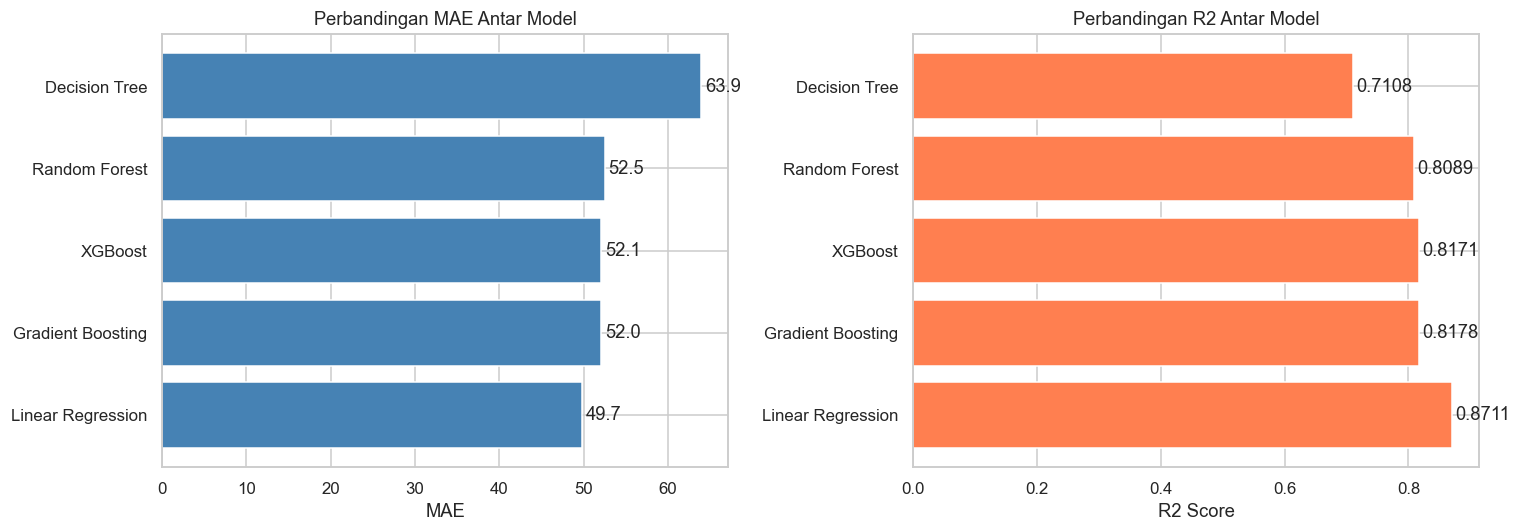

In [4]:
df_results = pd.DataFrame(results).sort_values('MAE')
print(df_results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
bars = ax.barh(df_results['Model'], df_results['MAE'], color='steelblue', edgecolor='white')
ax.set_xlabel('MAE')
ax.set_title('Perbandingan MAE Antar Model')
for bar, val in zip(bars, df_results['MAE']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center')

ax = axes[1]
bars = ax.barh(df_results['Model'], df_results['R2'], color='coral', edgecolor='white')
ax.set_xlabel('R2 Score')
ax.set_title('Perbandingan R2 Antar Model')
for bar, val in zip(bars, df_results['R2']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')

plt.tight_layout()
plt.savefig('../data/eval_01_comparison.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 6. Analisis Error per Jam

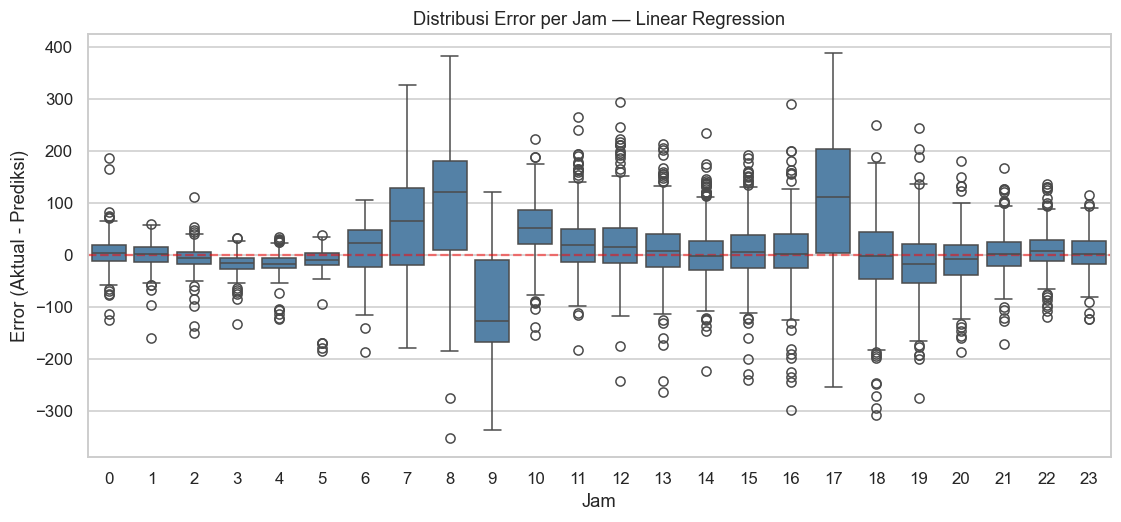

In [5]:
best_name = df_results.iloc[0]['Model']
best_pred = predictions[best_name]

test_hr = test.loc[test_valid, 'hr'].values
error_by_hour = pd.DataFrame({'hr': test_hr, 'error': y_test - best_pred})

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=error_by_hour, x='hr', y='error', ax=ax, color='steelblue')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title(f'Distribusi Error per Jam — {best_name}')
ax.set_xlabel('Jam')
ax.set_ylabel('Error (Aktual - Prediksi)')
plt.savefig('../data/eval_02_error_by_hour.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 7. Analisis Error per Musim

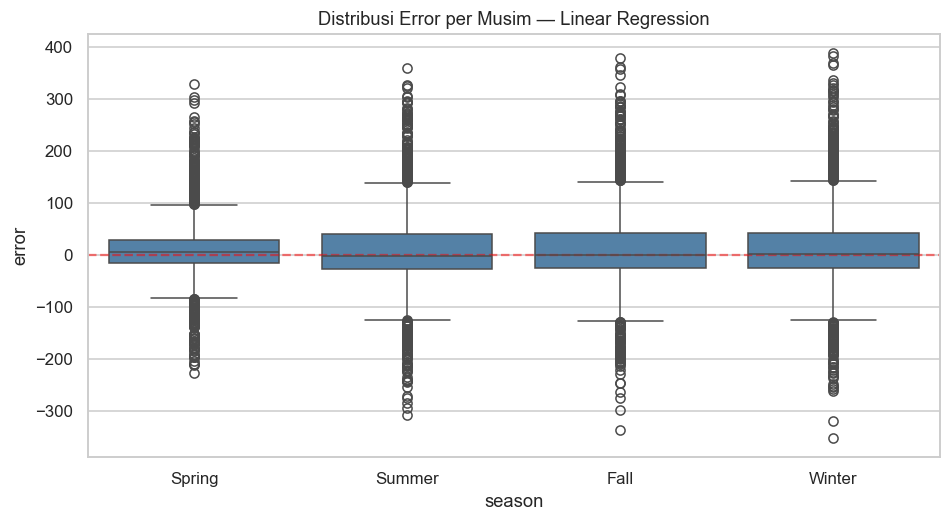

In [6]:
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
test_season = test.loc[test_valid, 'season'].map(season_map).values
error_by_season = pd.DataFrame({'season': test_season, 'error': y_test - best_pred})

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=error_by_season, x='season', y='error', ax=ax, order=['Spring','Summer','Fall','Winter'], color='steelblue')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title(f'Distribusi Error per Musim — {best_name}')
plt.savefig('../data/eval_03_error_by_season.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 8. Analisis Error per Kondisi Cuaca

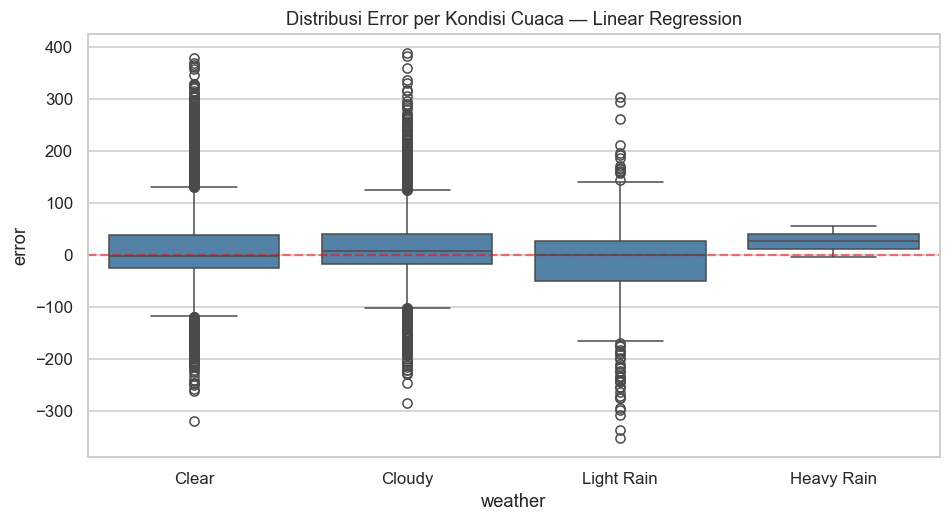

In [7]:
weather_map = {1: 'Clear', 2: 'Cloudy', 3: 'Light Rain', 4: 'Heavy Rain'}
test_weather = test.loc[test_valid, 'weathersit'].map(weather_map).values
error_by_weather = pd.DataFrame({'weather': test_weather, 'error': y_test - best_pred})

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=error_by_weather, x='weather', y='error', ax=ax, color='steelblue')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title(f'Distribusi Error per Kondisi Cuaca — {best_name}')
plt.savefig('../data/eval_04_error_by_weather.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 9. Residual Analysis

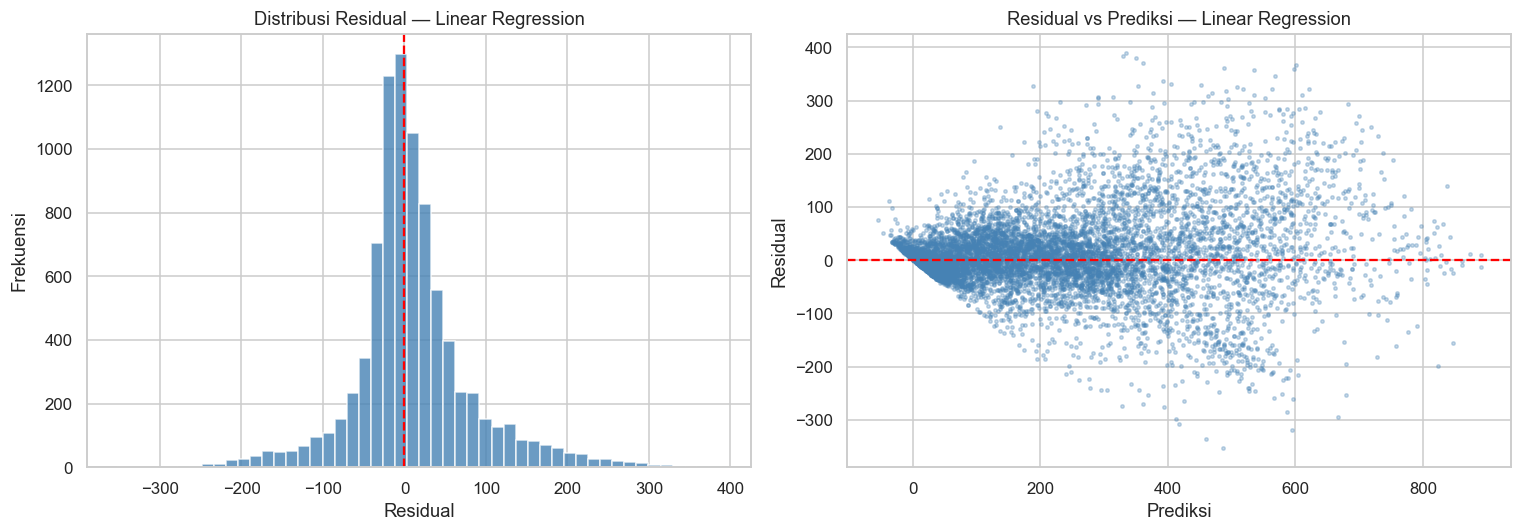

In [8]:
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_title(f'Distribusi Residual — {best_name}')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frekuensi')

axes[1].scatter(best_pred, residuals, alpha=0.3, s=5, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title(f'Residual vs Prediksi — {best_name}')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.savefig('../data/eval_05_residuals.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 10. Simpan Laporan Evaluasi

In [9]:
os.makedirs('../data', exist_ok=True)
df_results.to_csv('../data/evaluation_report.csv', index=False)
print('evaluation_report.csv berhasil disimpan.')

evaluation_report.csv berhasil disimpan.


---
## 11. Kesimpulan

**Model Terbaik:**
- Dipilih berdasarkan MAE dan R2.

**Pola Error:**
- Error bervariasi per jam — peak hours cenderung memiliki error lebih besar.
- Musim panas dan gugur memiliki error lebih tinggi.
- Cuaca ekstrem meningkatkan error.

**Rekomendasi:**
- Gunakan model terbaik untuk EXP-014 Dashboard.
- Pertimbangkan feature tambahan atau ensemble untuk peak hours.

**Next: EXP-014 Dashboard**